In [414]:
import numpy as np
import matplotlib.pyplot as plt
from pyrootmemo import Parameter
from pyrootmemo.stats import PowerRegression

# Power law regression

Power law regression is commonly used to describe the relationship between
root diameter and root strength, among others.

It takes the form:

$$ y(x) = y_0 \left(\frac{x}{x_0}\right)^\beta $$

where:
* $x$ is the independent variable, for example root diameter
* $y$ is the dependent variable, for example root tensile strength
* $x_0$ is a reference value. This is required to correctly account for units. By default, one unit of $x$ is assumed, so when $x$ described root diameter in millimetres, $x_0$ is equal to one millemeter. 
* $y_0$ is the power law multiplier: the value of $y$ at $x=x_0$.
* $\beta$ is the power law exponent

The default fitting uses non-linear least-squares regression.

* The fit residuals follow a normal distribution (normality assumption)
* the standard deviation describing this distribution does not depend on $x$ 
  (homoscedasticity assumption)

Nore that these assumptions are often not valid for root data. More advanced 
models can be used that are discussed later in this tutorial.

## Basic example - non-linear least-squared regression

Consider some tensile strength data for Maize plants measured by [Meijer (2025)](https://doi.org/10.1007/s11104-024-07007-9):

In [415]:
diameter = Parameter(
    [0.65, 0.81, 0.97, 1.00, 1.02, 1.02, 1.03, 1.03, 1.17, 1.17, 1.19, 1.19, 
     1.20, 1.21, 1.23, 1.25, 1.31, 1.31, 1.33, 1.37, 1.41, 1.42, 1.43, 1.53, 
     1.55, 1.66, 1.81, 1.83, 1.90, 1.92, 1.94, 1.94, 1.94, 1.95, 1.96, 1.99, 
     2.02, 2.03, 2.03, 2.31, 2.45, 2.59, 2.74, 2.81, 3.80, 3.89],
    'mm'
    )

strength = Parameter(
    [10.9, 16.7, 17.9, 9.6, 10.0, 20.0, 5.2, 13.4, 7.5, 6.7, 12.3, 5.9, 13.9,
     7.2, 10.3, 8.6, 19.4, 11.5, 9.0, 8.5, 9.9, 13.2, 7.7, 8.0, 7.5, 3.4, 7.3,
     4.4, 9.2, 10.5, 6.3, 12.7, 6.3, 8.5, 11.1, 11.8, 3.3, 14.6, 8.0, 8.8,
    5.6, 4.6, 9.2, 9.8, 3.0, 3.7], 
    'MPa'
    )

Units (e.g. millimetres, megapascals) are preserved throughout, ensuring no 
user-induced errors occur due to accidentical mishandling of units and 
conversions.

Create a fit object by calling the class:

In [416]:
fit = PowerRegression(diameter, strength)

The fitting results are stored as attributes: 

In [417]:
print(fit.multiplier)
print(fit.exponent)

11.687730351681905 megapascal
-0.528114500361542


To double-check the assumed reference value $x_0$:

In [418]:
print(fit.x0)

1.0 millimeter


Generate a simple plot to show the data and the fit

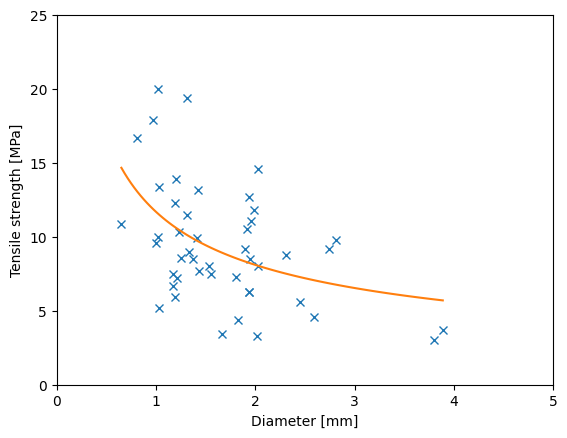

In [419]:
ax = fit.plot(x_label = 'Diameter', y_label = 'Tensile strength')

## Additional functionality

The created fit object has some useful methods, all of which are documented in 
the `PowerRegression` function. Some examples:

* `predict(x)`: Predict the fitted value of $y$ at known $x$-values

In [420]:
print(fit.predict(Parameter([2, 3, 4, 5], 'mm')))

[8.104978696273218 6.542677751097311 5.620482137285926 4.995672834683171] megapascal


* ` calc_ks()`: Calculate the Kolmogorov-Smirnov distance of the fit; a measure for how well 
the distribution of fit residuals matches the assumed distribution

In [421]:
print(fit.calc_ks())

0.13825802363145318


* `generate_random(x)`: Generate random values of $y$ at given $x$, using the 
fitted distribution of residuals

In [422]:
print(fit.generate_random(Parameter([1, 1, 1, 10, 10], 'mm')))

[11.40387123065545 13.80134366694622 15.365030341409923 1.1537735820526533 4.18854728701588] megapascal


* `calc_quantile(x, quantile)`: Calculate the $y$-value at given $x$ and 
cumulative probabilty density quantile, using the 
fitted distribution of residuals.

  For example, to calculate the value of $y$ at $x=4$ mm and at the 95% quantile 
  (so 95% of predicted values of $y$ at this value of $x$ will be lower than the
  returned result):

In [423]:
print(fit.calc_quantile(Parameter(1, 'mm'), 0.95))

17.535684434260276 megapascal


## Advanced fitting: models and weighting

### Fitting models

[Meijer (2025)](https://doi.org/10.1007/s11104-024-07007-9) investigated  a 
large number of root diameter versus tensile strength data sets and found:

1. Fit residuals are often not normally distributed
2. Residuals are not homoscedatic, but scales with the average tensile strength 
  for each diameter

This means assumptions behind 'tradiational' least-squares regression methods 
are not justified. [Meijer (2025)](https://doi.org/10.1007/s11104-024-07007-9) 
proposed a number of alternative fitting methods that can be called by defining 
the `method` when generating the fit:

| Fitting method | Assumed distribution of residuals | Assumed scaling of residuals | Desciptor of residuals in fit object |
|----|------|----|----|
| `gamma` | Gamma distribution | scales with $x^\beta$ | Shape parameter: `shape` |
| `gumbel` | Gumbel distribution | scales with $x^\beta$ | Shape parameter at $x=x_0$: `shape0` |
| `logistic` | Logistic distributions | scales with $x^\beta$ | Shape parameter at $x=x_0$: `shape` |
| `lognormal` | Lognormal distribution | scales with $x^\beta$ | Log-standard deviation `sdlog` |
| `normal` (default) | Normal (Gaussian) distribution | no scaling | Standard deviation: `sd_multiplier`|
| `normal_force` | Normal (Gaussian) distribution | scales with $x^{-2}$ | Standard deviation at $x=x_0$: `sd_multiplier`|
| `normal_scaled` | Normal (Gaussian) distribution | scales with $x^\beta$ | Standard deviation at $x=x_0$: `sd_multiplier` |
| `normal_freesd` | Normal (Gaussian) distribution | scales with $x^{\beta_\sigma}$ | Standard deviation at $x=x_0$: `sd_multiplier`, and `sd_exponent`: best-fitting value of $\beta_\sigma$ |
| `uniform` | Uniform distribution | scales with $x^\beta$ | Width parameter `width` |
| `weibull` | Weibull distribution | scales with $x^\beta$ | Shape parameter `shape` |

[Meijer (2025)](https://doi.org/10.1007/s11104-024-07007-9) found that the 
`gamma` method is generally most appropriate for root diameter versus root
tensile strength fitting.

For example, fitting using the `gamma` model gives different fitting parameter 
compared to least-squares regression. Its Kolmogorov-Smirmov distance is lower
and the 95% prediction intervals look more realistic, indicating the `gamma` 
model better describes the nature of the data.

gamma
multiplier: 11.944887548554417 megapascal
exponent: -0.5855915920022332
KS-distance: 0.09745925669148059
 
normal
multiplier: 11.687730351681905 megapascal
exponent: -0.528114500361542
KS-distance: 0.13825802363145318


Text(0.5, 1.0, 'Normal')

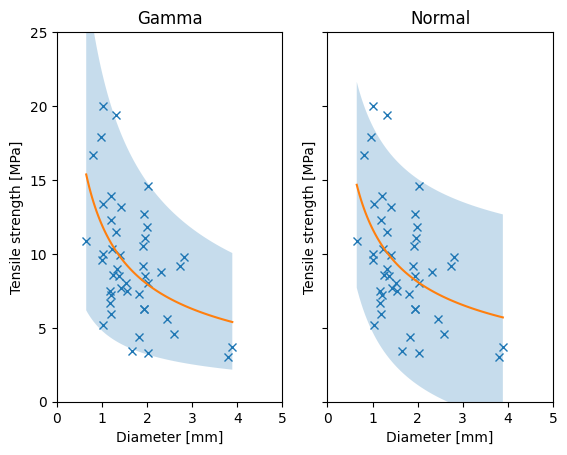

In [424]:
fit_gamma = PowerRegression(diameter, strength, 'gamma')

print('gamma')
print('multiplier: ' + str(fit_gamma.multiplier))
print('exponent: ' + str(fit_gamma.exponent))
print('KS-distance: ' + str(fit_gamma.calc_ks()))
print(' ')
print('normal')
print('multiplier: ' + str(fit.multiplier))
print('exponent: ' + str(fit.exponent))
print('KS-distance: ' + str(fit.calc_ks()))

fig, axs = plt.subplots(1, 2, sharex = True, sharey = True)
fit_gamma.plot(ax = axs[0], show_prediction = True, 
               x_label = 'Diameter', y_label = 'Tensile strength')
fit.plot(ax = axs[1], show_prediction = True,
         x_label = 'Diameter', y_label = 'Tensile strength')
axs[0].set_title('Gamma')
axs[1].set_title('Normal')

All models could be tested. For out example, the `lognormal` model results in 
the lower Kolmogorov-Smirnov distance, followed by the `gumbel` and `gamma` 
models.

['gamma: 0.097', 'gumbel: 0.08', 'logistic: 0.127', 'lognormal: 0.078', 'normal: 0.138', 'normal_force: 0.16', 'normal_scaled: 0.144', 'normal_freesd: 0.14', 'uniform: 0.194', 'weibull: 0.127']


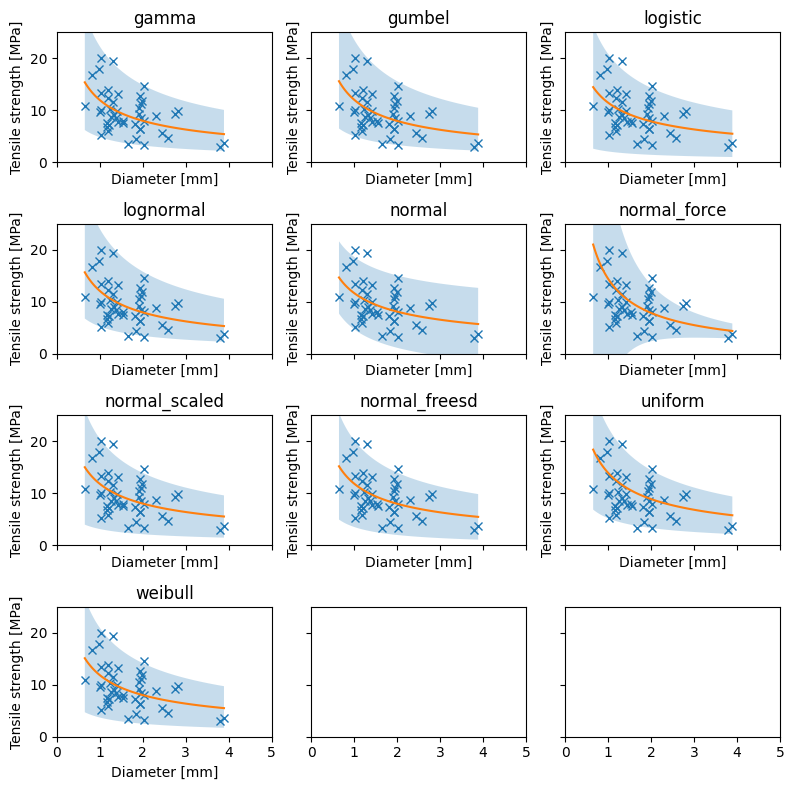

In [425]:
models = ['gamma', 'gumbel', 'logistic', 'lognormal', 'normal', 'normal_force',
          'normal_scaled','normal_freesd','uniform','weibull']
fits = [PowerRegression(diameter, strength, model = m) for m in models]

ks = [f.calc_ks() for f in fits]
print([m + ': ' + str(round(k, 3)) for m, k in zip(models, ks)])

fig, axs = plt.subplots(4, 3, sharex = True, sharey = True, figsize = (8, 8))
for m, f, a in zip(models, fits, axs[:len(models)].flatten()):
    f.plot(ax = a, show_prediction = True, x_label = 'Diameter', y_label = 'Tensile strength')
    a.set_title(m)
fig.tight_layout()

### Weighting

`PowerRegression` allows for weighting of each individual point through 
specifying the `weights` input field. Weights must always be non-dimensional.

For example, consider a `normal` fit where larger-diameter roots are weighted 
more heavily, for example by weighing proportional to the root cross-sectional 
area:

12.320276316160927 megapascal
-0.6473972190915009


Text(0.5, 1.0, 'Normal (weighted)')

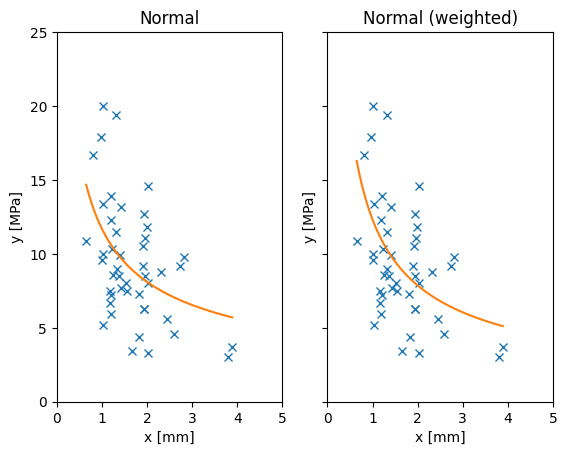

In [426]:
weights = np.array(diameter.value)**2
fit_weighted = PowerRegression(diameter, strength, 'normal', weights = weights)

print(fit_weighted.multiplier)
print(fit_weighted.exponent)

fig, axs = plt.subplots(1, 2, sharex = True, sharey = True)
fit.plot(ax = axs[0])
fit_weighted.plot(ax = axs[1])
axs[0].set_title('Normal')
axs[1].set_title('Normal (weighted)')

This shows that the fit is pulled down more at larger values of $x$ compared
to the non-weighted fit.